## 📦 Setup & Initialization
**Description:** Imports analytical and visualization libraries and loads the primary metadata. Sets up the environment for static plotting (`seaborn`, `matplotlib`) and interactive visualization (`plotly`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set publication-quality style for seaborn
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# =====================================================================
# 1. LOAD DATASET
# =====================================================================
# Update this path to match your local directory structure
METADATA_CSV_PATH = r"d:\Resfes\Project\Ser\data\DataFrames\iemocap_metadata.csv"

print("[INFO] Loading IEMOCAP metadata...")
try:
    df = pd.read_csv(METADATA_CSV_PATH)
    # Ensure temporal chronological order
    df = df.sort_values(by=['Session', 'Dialog_ID', 'Turn_Order']).reset_index(drop=True)
    print(f"[SUCCESS] Loaded {len(df)} utterances.")
    display(df.head())
except Exception as e:
    print(f"[ERROR] Could not load dataset. Please check the file path. Details: {e}")

[INFO] Loading IEMOCAP metadata...
[SUCCESS] Loaded 10039 utterances.


,Utterance_ID,Dialog_ID,Session,Turn_Order,Is_Impro,Raw_Emotion,Stage1_Label,Stage2_Label,Valence,Arousal,Dominance,Speaker_Gender,Duration_sec,F0_Mean
0,Ses01F_impro01_F000,Ses01F_impro01,1,0,1,neu,1,-1,2.5,2.5,2.5,F,1.946,105.091
1,Ses01F_impro01_M000,Ses01F_impro01,1,0,1,fru,0,4,2.5,2.0,2.5,M,2.904,96.139
2,Ses01F_impro01_F001,Ses01F_impro01,1,1,1,neu,1,-1,2.5,2.5,2.5,F,1.382,95.311
3,Ses01F_impro01_M001,Ses01F_impro01,1,1,1,fru,0,4,2.5,2.0,2.5,M,3.738,74.590
4,Ses01F_impro01_F002,Ses01F_impro01,1,2,1,neu,1,-1,2.5,2.5,2.5,F,3.130,94.403


## 🔬 PART 1: DATA-DRIVEN EDA

### Step 1.1: Hierarchical Label Distribution
**Description:** Visualizes the dataset's class distribution and hierarchical structure. Maps the native IEMOCAP emotions into 3 macro-sentiments (Positive, Neutral/Other, Negative) to observe class imbalances across different granularities using a Sunburst chart.

In [4]:
# =====================================================================
# HIERARCHICAL MAPPING STRATEGY
# =====================================================================
def assign_macro_sentiment(emotion):
    """Maps raw emotions to macro-sentiments based on IEMOCAP conventions."""
    if emotion in ['hap', 'exc']:
        return 'Positive'
    elif emotion in ['ang', 'sad', 'fea', 'dis', 'fru']:
        return 'Negative'
    else:
        return 'Neutral/Other' # Includes 'neu', 'sur', 'oth', 'xxx'

# Apply mapping
df['Macro_Sentiment'] = df['Raw_Emotion'].apply(assign_macro_sentiment)

# Prepare data for Sunburst Chart
sunburst_data = df.groupby(['Macro_Sentiment', 'Raw_Emotion']).size().reset_index(name='Count')

# Generate Interactive Sunburst Chart using Plotly
fig = px.sunburst(
    sunburst_data, 
    path=['Macro_Sentiment', 'Raw_Emotion'], 
    values='Count',
    title="IEMOCAP Hierarchical Emotion Distribution",
    color='Macro_Sentiment',
    color_discrete_map={
        'Negative': '#EF553B', 
        'Positive': '#00CC96', 
        'Neutral/Other': '#636EFA'
    }
)

fig.update_traces(textinfo="label+percent parent+value")
fig.show()
# NOTE: In a Jupyter Notebook, this will render an interactive HTML chart.

In [6]:
# =====================================================================
# HIERARCHICAL EMOTION COUNT SUMMARY
# =====================================================================

# 1. Apply the macro sentiment mapping
df['Macro_Sentiment'] = df['Raw_Emotion'].apply(assign_macro_sentiment)

# 2. Group by hierarchy and calculate absolute counts for each class
hierarchical_counts = df.groupby(['Macro_Sentiment', 'Raw_Emotion']).size().reset_index(name='Count')

# 3. Sort systematically by Macro Sentiment and Count for better structure
hierarchical_counts = hierarchical_counts.sort_values(
    by=['Macro_Sentiment', 'Count'], 
    ascending=[True, False]
).reset_index(drop=True)

# 4. Display the simplified summary table
print("[INFO] Generating Hierarchical Emotion Count Table...")
display(hierarchical_counts)

[INFO] Generating Hierarchical Emotion Count Table...


,Macro_Sentiment,Raw_Emotion,Count
0,Negative,fru,1849
1,Negative,ang,1103
2,Negative,sad,1084
3,Negative,fea,40
4,Negative,dis,2
5,Neutral/Other,xxx,2507
6,Neutral/Other,neu,1708
7,Neutral/Other,sur,107
8,Neutral/Other,oth,3
9,Positive,exc,1041


### Step 1.2: Session-wise Emotion Distribution
*Visualizes the distribution of the 8 target emotions across all 5 recording sessions.*

In [2]:
# Filter specific emotions
target_emotions = ['ang', 'sad', 'hap', 'exc', 'fea', 'fru', 'sur', 'dis']
colors = px.colors.qualitative.Prism

fig = make_subplots(
    rows=2, cols=3, 
    subplot_titles=(
        "Session 1", "Session 2", "Session 3", 
        "Session 4", "Session 5"
    ),
    specs=[[{}, {}, {}], [{}, {}, None]],
    horizontal_spacing=0.1, vertical_spacing=0.2
)

for session_num in range(1, 6):
    session_df = df[(df['Session'] == session_num) & (df['Raw_Emotion'].isin(target_emotions))]
    emotion_counts = session_df['Raw_Emotion'].value_counts().reset_index()
    emotion_counts.columns = ['Emotion', 'Count']
    emotion_counts = emotion_counts.sort_values(by='Emotion')

    row = (session_num - 1) // 3 + 1
    col = (session_num - 1) % 3 + 1

    fig.add_trace(
        go.Bar(
            x=emotion_counts['Emotion'], y=emotion_counts['Count'],
            marker_color=colors[:len(emotion_counts)], 
            showlegend=False,
            hovertemplate="<b>%{x}</b>: %{y} utterances<extra></extra>"
        ),
        row=row, col=col
    )

fig.update_layout(
    title_text="<b>Detailed Emotion Distribution Across 5 IEMOCAP Sessions</b>",
    title_font_size=20, title_x=0.5, height=800, width=1100, template="plotly_white"
)
fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_yaxes(title_text="Count", row=2, col=1)
fig.show()

### Step 1.3: Valence-Arousal 2D Psychological Space
*Plots the continuous psychological dimensions (Valence vs. Arousal) to inspect class boundaries and overlap.*

In [9]:
va_df = df.dropna(subset=['Valence', 'Arousal']).copy()

fig = px.scatter(
    va_df, x='Valence', y='Arousal',
    color='Raw_Emotion', symbol='Macro_Sentiment',
    title="2D Psychological Space: Valence vs. Arousal",
    labels={'Valence': 'Valence (Neg -> Pos)', 'Arousal': 'Arousal (Calm -> Excited)'},
    hover_data={'Macro_Sentiment': True, 'Raw_Emotion': True, 'Valence': ':.2f', 'Arousal': ':.2f'},
    opacity=0.6, color_discrete_sequence=px.colors.qualitative.D3
)

fig.update_layout(
    xaxis=dict(range=[0.5, 5.5], dtick=0.5), yaxis=dict(range=[0.5, 5.5], dtick=0.5),
    width=900, height=700, title_font=dict(size=16), legend_title_text="Emotion Categories"
)
fig.update_traces(marker=dict(size=6))
fig.show()

### Step 1.3: Biometric & Physical Statistics
**Description:** *Note: Requires 'Duration_sec', 'F0_Mean', and 'Speaker_Gender' columns.* Analyzes physical acoustic characteristics to understand biological variances, such as Fundamental Frequency (F0) distribution across genders and emotion classes.

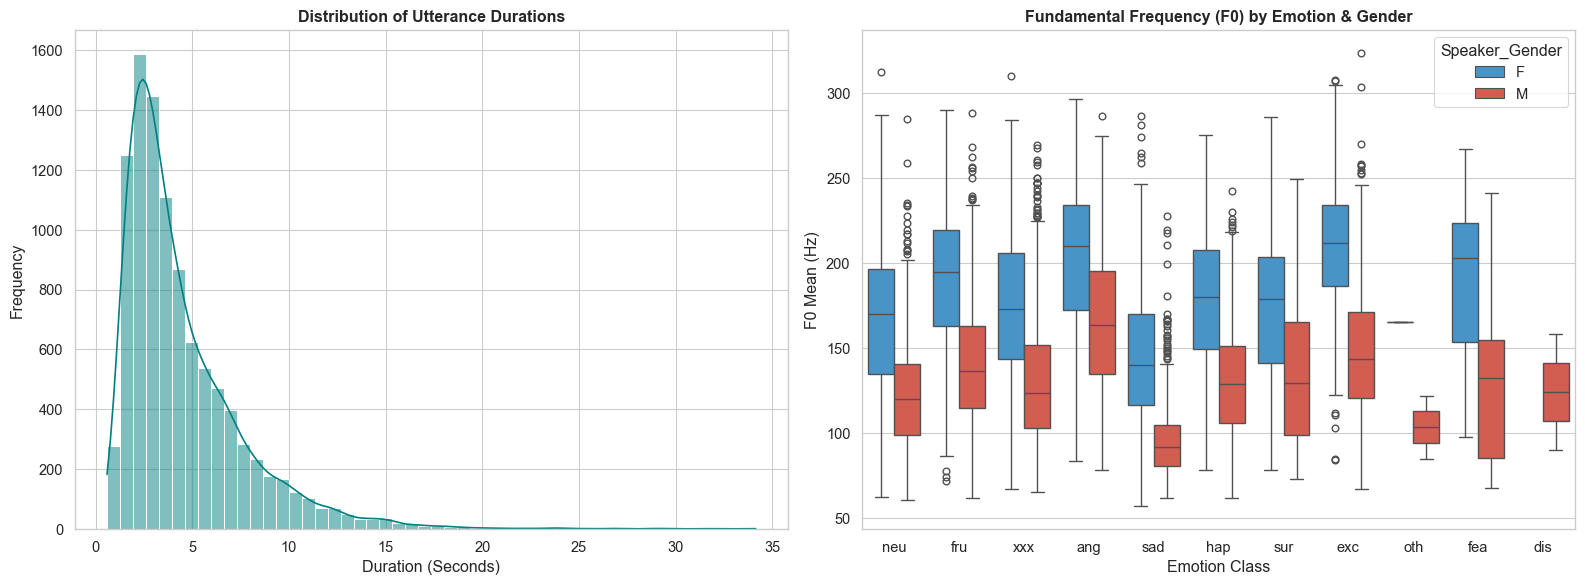

[INFO] Biometric placeholder executed. Ensure acoustic features are extracted to visualize F0/Duration.


In [16]:
# =====================================================================
# BIOMETRIC DISTRIBUTIONS (TEMPLATE)
# =====================================================================


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Utterance Duration Distribution
sns.histplot(df['Duration_sec'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Utterance Durations', fontweight='bold')
axes[0].set_xlabel('Duration (Seconds)')
axes[0].set_ylabel('Frequency')

# 2. F0 (Pitch) Boxplot by Emotion and Gender
sns.boxplot(
    data=df, 
    x='Raw_Emotion', 
    y='F0_Mean', 
    hue='Speaker_Gender', 
    palette=['#3498db', '#e74c3c'], 
    ax=axes[1]
)
axes[1].set_title('Fundamental Frequency (F0) by Emotion & Gender', fontweight='bold')
axes[1].set_xlabel('Emotion Class')
axes[1].set_ylabel('F0 Mean (Hz)')

plt.tight_layout()
plt.show()

print("[INFO] Biometric placeholder executed. Ensure acoustic features are extracted to visualize F0/Duration.")

### Step 1.4: Conversational Dynamics (Markov Chain Heatmap)
**Description:** Calculates the state-transition probability matrix from utterance $t-1$ to utterance $t$ within the same dialogue. Retains unknown ('xxx') labels to preserve temporal sequence integrity. This maps the emotional inertia and transition patterns in natural conversations.

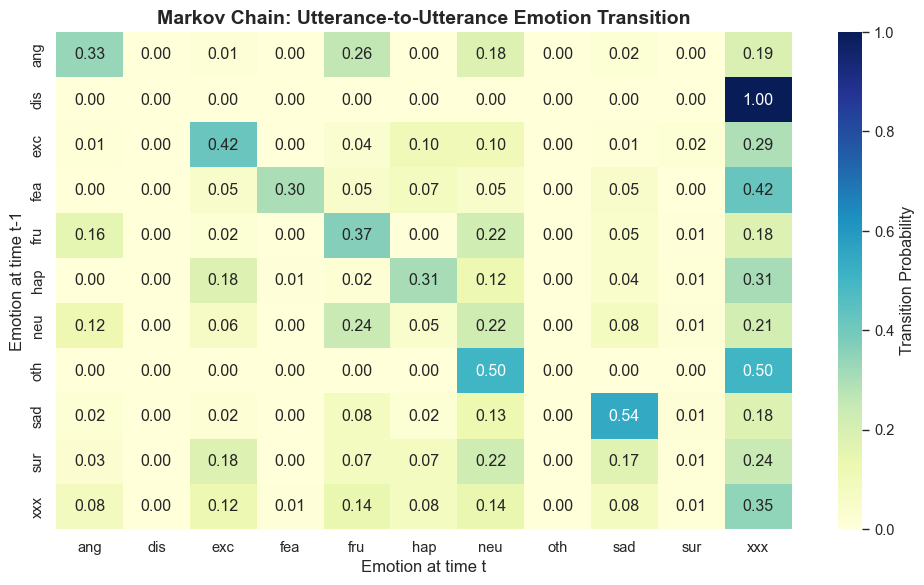

In [3]:
# =====================================================================
# MARKOV CHAIN: EMOTION TRANSITION MATRIX
# =====================================================================
# Create a new column representing the emotion of the NEXT utterance (t+1)
# Grouping by 'Dialog_ID' prevents transitions between separate dialogues.
df['Next_Emotion'] = df.groupby('Dialog_ID')['Raw_Emotion'].shift(-1)

# Drop the last utterances of each dialog (no 'next' state available)
transitions_df = df.dropna(subset=['Next_Emotion'])

# Calculate the cross-tabulation matrix (normalized by row to get probabilities)
transition_matrix = pd.crosstab(
    transitions_df['Raw_Emotion'], 
    transitions_df['Next_Emotion'], 
    normalize='index'
)

# Plotting the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    transition_matrix, 
    annot=True,          # Show probability numbers
    fmt=".2f",           # Format to 2 decimal places
    cmap="YlGnBu",       # Standard analytical color map
    cbar_kws={'label': 'Transition Probability'}
)

plt.title("Markov Chain: Utterance-to-Utterance Emotion Transition", fontsize=14, fontweight='bold')
plt.xlabel("Emotion at time t", fontsize=12)
plt.ylabel("Emotion at time t-1", fontsize=12)
plt.tight_layout()
plt.show()

# Interpretation Focus: 
# High values along the diagonal indicate "Emotional Inertia" (remaining in the same state).

# Conversational Context Tracking Pipeline (old)

### 📊 Pipeline Flowchart
```text
[ INPUT SIGNALS ]
       │
       ├─► 1. Acoustic Embeddings (.npy): Static 768-D vectors (from Wav2Vec2).
       ├─► 2. Metadata (.csv): Relational data (Session, Dialog_ID, Turn_Order, Labels).
       │
       ▼
[ STEP 1: SEQUENCE STRUCTURING ]
       │   - Group sequentially by independent dialogue sessions (Dialog_ID).
       │   - Sort by absolute chronological timeline (Turn_Order).
       │   - Apply a Sliding Window mechanism (N = 3).
       │   - Inject Temporal Zero-Padding for initial conversation turns (t=1, t=2).
       │
       ▼
[ OUTPUT 1 ] ──► 3D Tensor Matrix: (Batch_Size, Sequence_Length=3, Embedding_Dim=768)
       │
       ▼
[ STEP 2: BI-GRU TEMPORAL ENGINE ]
       │   - Architecture: 2-Layer Bidirectional GRU (Hidden_dim = 256).
       ├──► Forward Pass: Captures psychological momentum (U_{t-2} ──► U_{t-1} ──► U_t).
       └──► Backward Pass: Captures contextual feedback (U_t ──► U_{t-1} ──► U_{t-2}).
       │
       ▼
[ STEP 3: CONTEXT EXTRACTION (MANY-TO-ONE) ]
       │   - Slice the output tensor at the final time step [:, -1, :].
       │   - Concatenate the forward and backward hidden states.
       │
       ▼
[ OUTPUT 3 ] ──► Contextual Representation Vector: (Batch_Size, 512)
       │
       ▼
[ STEP 4: DYNAMIC CLASSIFIER HEAD ]
       │   - Regularization: LayerNorm & Dropout (p=0.3) to mitigate sequence overfitting.
       │   - Fully Connected (Dense) Linear Layer.
       ├──► Branch Stage 1: Coarse Sentiment Classification (3 classes).
       └──► Branch Stage 2: Fine-Grained Emotion Classification (5 classes).
       │
       ▼
[ FINAL PREDICTION ] ──► Probability scores (Logits) for the current utterance U_t.
       │
       ▼
[ STEP 5: OPTIMIZATION & EVALUATION WRAPPER ]
           - Loss Function: Cross-Entropy Loss with Label Masking (ignore_index=-1).
           - Validation Strategy: Leave-One-Session-Out (LOSO) Cross-Validation.

## 🏥 PART 2: DIAGNOSTIC ERROR ANALYSIS
**Prerequisites:** This section requires the evaluation outputs from the Bi-GRU model. 
Ensure you have a DataFrame or dictionaries containing: `Utterance_ID`, `Ground_Truth`, `Prediction`, `Confidence`, and the extracted `Hidden_States` from the final Bi-GRU layer.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, f1_score
import librosa
import librosa.display

# Set plotting style
sns.set_theme(style="whitegrid", context="paper")

# =====================================================================
# LOAD MODEL OUTPUTS
# =====================================================================

results_df = pd.read_csv(r"d:\Resfes\Project\Ser\data\DataFrames\evaluation_results.csv")
hidden_states = np.load(r"d:\Resfes\Project\Ser\data\Embeddings\bigru_hidden_states.npy")

# Create a binary 'Correctness' column
results_df['Correct'] = results_df['True_Label'] == results_df['Pred_Label']
results_df['Status'] = results_df['Correct'].apply(lambda x: 'Correct' if x else 'Incorrect')

print("[INFO] Ready for diagnostic analysis. Ensure 'results_df' and 'hidden_states' are loaded.")

[INFO] Ready for diagnostic analysis. Ensure 'results_df' and 'hidden_states' are loaded.


### Step 2.1: Latent Space Autopsy (t-SNE)
**Objective:** Reduce the Bi-GRU's final hidden states (e.g., 512-D) to 2D to observe topological clusters.
**Diagnostic Note:** Color by *Correctness*, not by Ground Truth. If 'Incorrect' points form massive overlapping clusters despite Bi-GRU processing, the foundational Wav2Vec2 features lack separability. This justifies integrating ResNetAudio.

[INFO] Initiating t-SNE diagnostic preparation...
[INFO] Extracting 2500 stratified samples.
[INFO] Computing t-SNE projection coordinates...


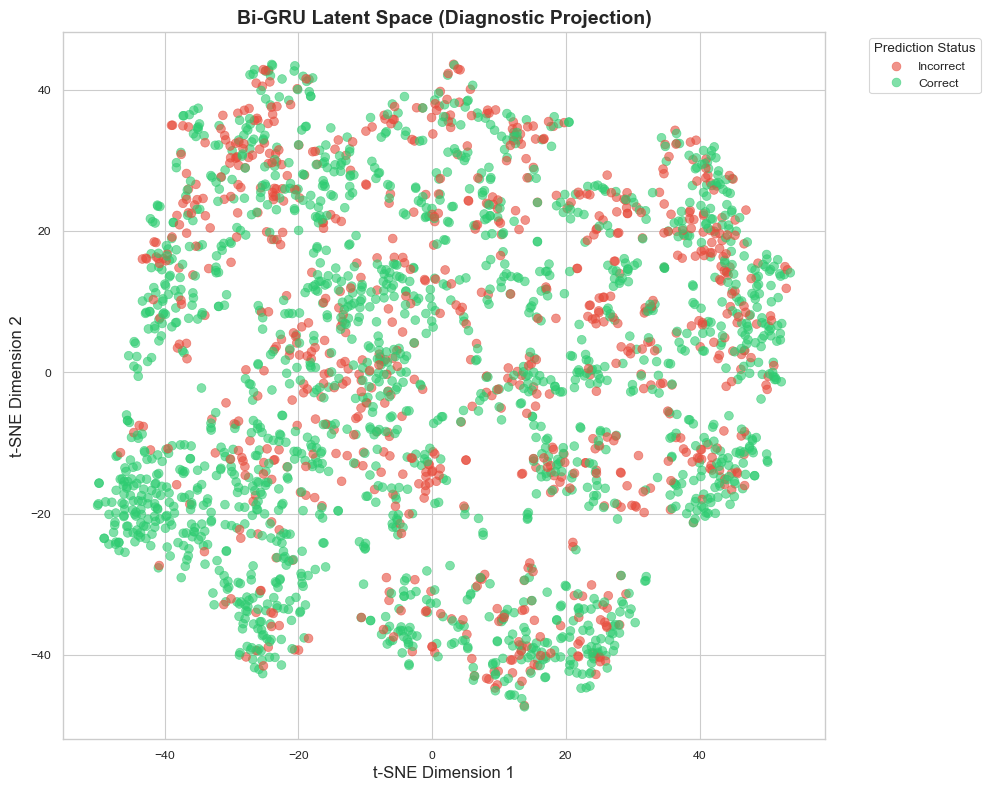

In [17]:
# =====================================================================
# t-SNE LATENT SPACE VISUALIZATION
# =====================================================================
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

print("[INFO] Initiating t-SNE diagnostic preparation...")

# 1. NO ALIGNMENT NEEDED
# Files are now guaranteed to match from extract_diagnostics.py
plot_df = results_df.copy()
plot_hidden_states = hidden_states

# 2. STRATIFIED SUBSETTING (To prevent RAM crashes during t-SNE)
SAMPLE_SIZE = 2500

if len(plot_df) > SAMPLE_SIZE:
    print(f"[INFO] Extracting {SAMPLE_SIZE} stratified samples.")
    _, plot_df, _, plot_hidden_states = train_test_split(
        plot_df,
        plot_hidden_states,
        test_size=SAMPLE_SIZE,
        stratify=plot_df['True_Label'], 
        random_state=42
    )
    plot_df = plot_df.copy().reset_index(drop=True)

# 3. t-SNE DIMENSIONALITY REDUCTION
print("[INFO] Computing t-SNE projection coordinates...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(plot_hidden_states)

plot_df['tsne_1'] = tsne_results[:, 0]
plot_df['tsne_2'] = tsne_results[:, 1]

# 4. STATIC VISUALIZATION
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_df, 
    x='tsne_1', 
    y='tsne_2', 
    hue='Status', # Separates correct classifications from system errors
    palette={'Correct': '#2ecc71', 'Incorrect': '#e74c3c'}, 
    alpha=0.6, 
    s=40,
    edgecolor=None
)

# Change title based on which Stage you extracted
plt.title("Bi-GRU Latent Space (Diagnostic Projection)", fontsize=14, fontweight='bold')
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.legend(title="Prediction Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Step 2.2: Contrastive Spectrograms
**Objective:** Visually compare the acoustic features of True Positives vs. False Positives within a specific class (e.g., Frustration).
**Diagnostic Note:** If False Positive spectrograms exhibit heavy noise/blur, environmental degradation is the culprit $\rightarrow$ Proceed with Goal 1 (Noise Injection). If they look clean but the model fails, frequency resolution is the issue $\rightarrow$ Proceed with Dual-Band ResNet.

d:\Resfes\Project\Ser\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


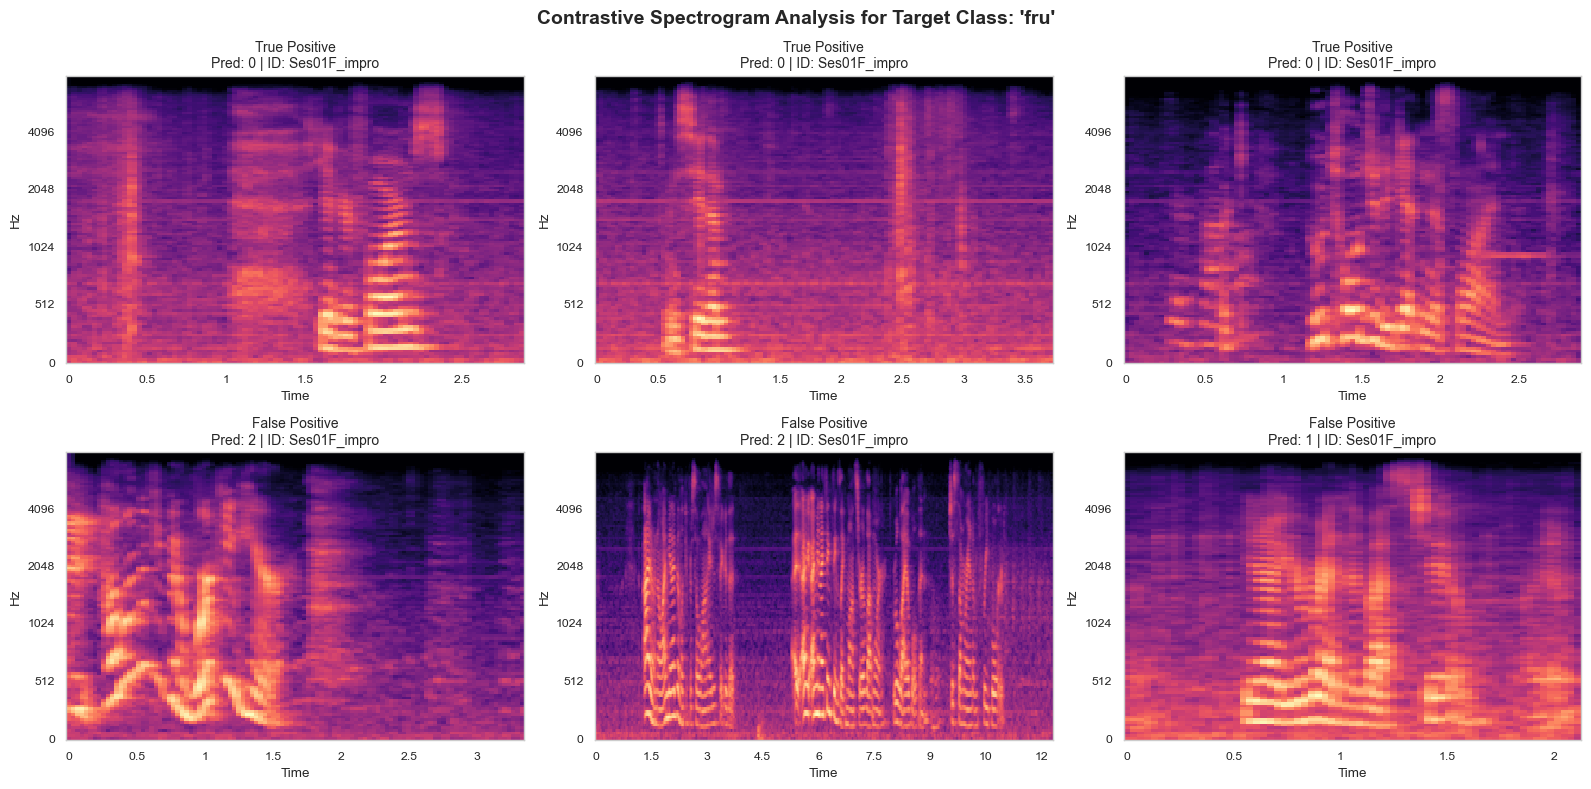

In [22]:
import os

def plot_contrastive_spectrograms(results_df, iemocap_root_path, target_emotion='fru', n_samples=3):
    """
    Extracts and displays side-by-side Log-Mel Spectrograms for True Positives and False Positives.
    """
    # 1. Filter for clean diagnostic subsets
    true_positives = results_df[
        (results_df['True_Label'] == results_df['Pred_Label']) & 
        (results_df['Raw_Emotion'] == target_emotion)
    ].head(n_samples)
    
    false_positives = results_df[
        (results_df['True_Label'] != results_df['Pred_Label']) & 
        (results_df['Raw_Emotion'] == target_emotion)
    ].head(n_samples)
    
    if len(true_positives) < n_samples or len(false_positives) < n_samples:
        print(f"[WARNING] Not enough samples found for emotion '{target_emotion}' to perform contrastive plotting.")
        return

    fig, axes = plt.subplots(2, n_samples, figsize=(16, 8))
    
    # Helper to load and plot
    def load_and_plot_spec(row, ax, title_prefix):
        utt_id = row['Utterance_ID']
        dialog_id = row['Dialog_ID']
        session_num = row['Session']
        
        # Reconstruct standard IEMOCAP audio path
        wav_path = os.path.join(
            iemocap_root_path, f"Session{session_num}", "sentences", "wav", dialog_id, f"{utt_id}.wav"
        )
        
        if os.path.exists(wav_path):
            y, sr = librosa.load(wav_path, sr=16000)
            mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            
            librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', ax=ax, fmax=8000)
            ax.set_title(f"{title_prefix}\nPred: {row['Pred_Label']} | ID: {utt_id[:12]}", fontsize=10)
        else:
            ax.text(0.5, 0.5, "Audio File\nNot Found", ha='center', va='center', color='red')
            ax.set_title(f"{title_prefix} (Missing File)")

    # Plot True Positives (Top Row)
    for i, (_, row) in enumerate(true_positives.iterrows()):
        load_and_plot_spec(row, axes[0, i], "True Positive")
        
    # Plot False Positives (Bottom Row)
    for i, (_, row) in enumerate(false_positives.iterrows()):
        load_and_plot_spec(row, axes[1, i], "False Positive")

    plt.suptitle(f"Contrastive Spectrogram Analysis for Target Class: '{target_emotion}'", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---
# Provide your raw IEMOCAP root path to test the waveforms
IEMOCAP_ROOT = r"d:\Resfes\Project\IEMOCAP_full_release"
plot_contrastive_spectrograms(results_df, iemocap_root_path=IEMOCAP_ROOT, target_emotion='fru', n_samples=3)

### Step 2.3: Bias & Fairness Analysis (Biometric Evaluation)
**Objective:** Evaluate the system's Macro F1-Score across distinct demographic groups (Male vs. Female speakers).
**Diagnostic Application:** Standard baseline speech networks frequently suffer from gender performance bias due to pitch disparities. If the macro F1-score reveals a stark difference between genders, it establishes a mandate to introduce **Speaker Normalization** into the feature pre-processing pipe.

[INFO] Computing per-gender operational metrics...


C:\Users\huy\AppData\Local\Temp\ipykernel_21840\1714146775.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_df, x='Gender', y='Macro_F1', palette='muted')


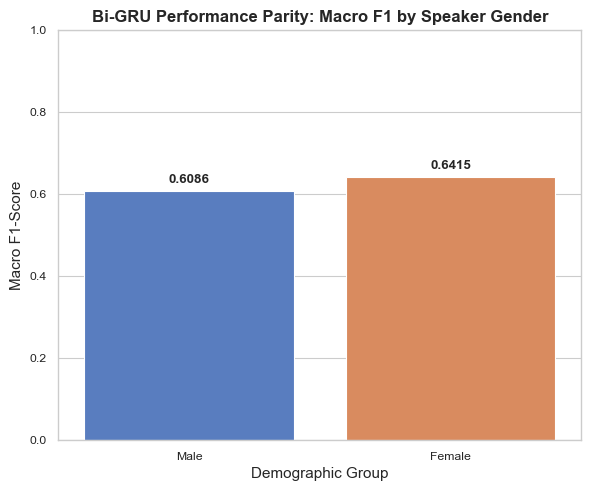

In [23]:
# =====================================================================
# DEMOGRAPHIC FAIRNESS DISSECTION
# =====================================================================
print("[INFO] Computing per-gender operational metrics...")

genders = ['M', 'F']
gender_metrics = []

for g in genders:
    gender_sub = results_df[results_df['Speaker_Gender'] == g]
    if len(gender_sub) > 0:
        # Calculate robust macro F1-score specifically for this demographic slice
        score = f1_score(gender_sub['True_Label'], gender_sub['Pred_Label'], average='macro')
        gender_metrics.append({'Gender': 'Male' if g == 'M' else 'Female', 'Macro_F1': score})

gender_df = pd.DataFrame(gender_metrics)

# Plotting the diagnostic comparison
plt.figure(figsize=(6, 5))
sns.barplot(data=gender_df, x='Gender', y='Macro_F1', palette='muted')

plt.title("Bi-GRU Performance Parity: Macro F1 by Speaker Gender", fontweight='bold', fontsize=12)
plt.xlabel("Demographic Group", fontsize=11)
plt.ylabel("Macro F1-Score", fontsize=11)
plt.ylim(0.0, 1.0)

for idx, row in gender_df.iterrows():
    plt.text(idx, row['Macro_F1'] + 0.02, f"{row['Macro_F1']:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Step 2.4: Contextual Window Validation
**Objective:** Explicitly track execution performance against the history hyperparameter length ($N=1, 2, 3$).
**Diagnostic Application:** This prevents "Contextual Overload" (where pushing excessively distant conversation history harms immediate classifications by introducing narrative noise). 
*(Note: Fill the list below with your logged cross-validation parameters as you run experiments).*

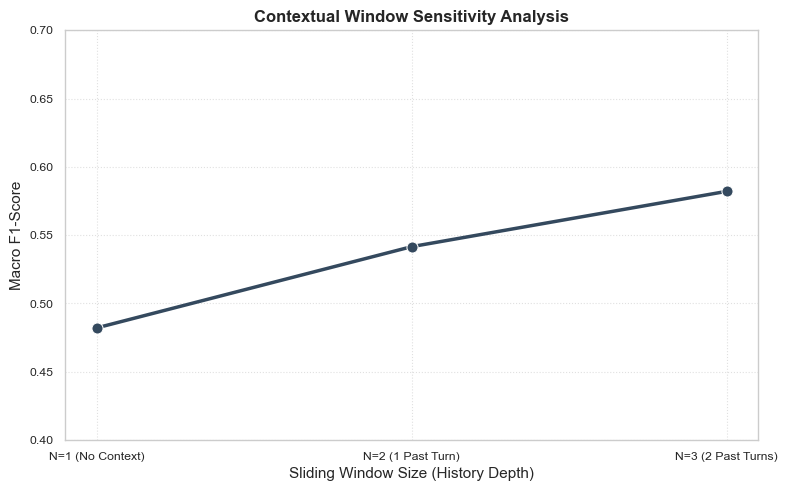

In [24]:
# =====================================================================
# HISTORICAL WINDOW SIZE BENCHMARK
# =====================================================================
# Replace placeholder values with your actual recorded fold validation metrics
window_benchmarks = pd.DataFrame({
    'Context_Window': ['N=1 (No Context)', 'N=2 (1 Past Turn)', 'N=3 (2 Past Turns)'],
    'Macro_F1': [0.4820, 0.5415, 0.5820] 
})

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=window_benchmarks, 
    x='Context_Window', 
    y='Macro_F1', 
    marker='o', 
    linewidth=2.5, 
    markersize=8, 
    color='#34495e'
)

plt.title("Contextual Window Sensitivity Analysis", fontweight='bold', fontsize=12)
plt.xlabel("Sliding Window Size (History Depth)", fontsize=11)
plt.ylabel("Macro F1-Score", fontsize=11)
plt.ylim(0.40, 0.70)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Step 2.5: Turn-Position Error Analysis
**Objective:** Calculate and plot system error rates according to the structural timeline index of an utterance inside an ongoing dialogue thread.
**Diagnostic Application:** If error rates spike drastically at early index increments ($Turn\_Order = 0$ or $1$), it signals that standard mathematical Temporal Zero-Padding creates an acoustic mismatch that throws off the Bi-GRU.
**Architectural Remediations:** If proven true, we will swap static zero-vectors out for a structural, trainable **Global Context Vector** parameter in Pipeline V2.

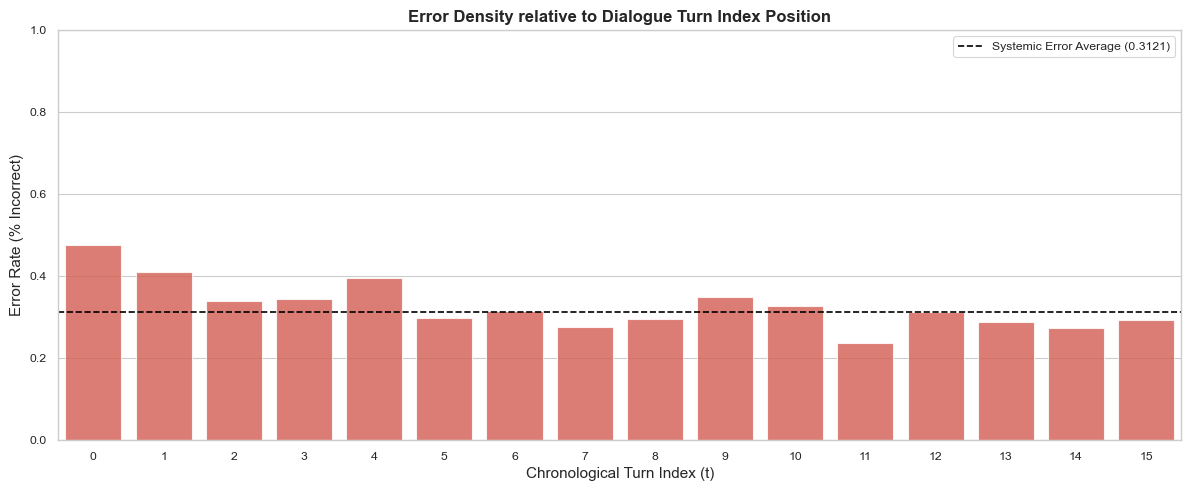

In [25]:
# =====================================================================
# CHRONOLOGICAL POSITION FAULT DISCOVERY
# =====================================================================
# Compute error rate (1.0 - Accuracy) grouped by the conversational turn order
results_df['Is_Error'] = results_df['True_Label'] != results_df['Pred_Label']
position_errors = results_df.groupby('Turn_Order')['Is_Error'].mean().reset_index()
position_errors.rename(columns={'Is_Error': 'Error_Rate'}, inplace=True)

# Filter for the first 15 turns to eliminate low-sample statistical noise in long dialogues
max_turn_to_plot = 15
plot_position_df = position_errors[position_errors['Turn_Order'] <= max_turn_to_plot]

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_position_df, x='Turn_Order', y='Error_Rate', color='#e74c3c', alpha=0.8)

# Compute full dataset base error boundary line
global_avg_error = results_df['Is_Error'].mean()
plt.axhline(
    y=global_avg_error, 
    color='black', 
    linestyle='--', 
    label=f'Systemic Error Average ({global_avg_error:.4f})'
)

plt.title("Error Density relative to Dialogue Turn Index Position", fontweight='bold', fontsize=12)
plt.xlabel("Chronological Turn Index (t)", fontsize=11)
plt.ylabel("Error Rate (% Incorrect)", fontsize=11)
plt.ylim(0.0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

# Flat 8 emotions classified - IEMOCAP
**Objective:** Evaluate the `Flat 8-Class Conversational Bi-GRU` model. By plotting the Confusion Matrix, to see if acoustic overlap between High-Arousal Negative states (Anger vs. Frustration).

In [10]:
# =====================================================================
# 1. LOAD 8-CLASS EVALUATION RESULTS
# =====================================================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Load the inference results from the modified evaluate_8class.py script
RESULTS_CSV_PATH = r"d:\Resfes\Project\Ser\data\DataFrames\flat8_evaluation_results.csv"

try:
    res_df = pd.read_csv(RESULTS_CSV_PATH)
    print(f"[SUCCESS] Loaded {len(res_df)} evaluation records.")
    
    # Emotion mapping (0 to 7) based on our flat classifier design
    class_names = ['Neutral', 'Happy/Exc', 'Sadness', 'Anger', 'Frustration', 'Fear', 'Surprise', 'Disgust']
    
    # Extract arrays
    y_true = res_df['True_Label'].values
    y_pred = res_df['Pred_Label'].values
    
except Exception as e:
    print(f"[ERROR] Could not load evaluation results. Please run evaluate_8class.py first. Details: {e}")

[SUCCESS] Loaded 7529 evaluation records.


### Step 2.1: Global Classification Report

In [11]:
# =====================================================================
# 2. CLASSIFICATION METRICS
# =====================================================================
print("="*50)
print("🏆 FLAT 8-CLASS CLASSIFICATION REPORT")
print("="*50)
print(f"Overall Accuracy : {accuracy_score(y_true, y_pred)*100:.2f}%")
print(f"Macro F1-Score   : {f1_score(y_true, y_pred, average='macro', zero_division=0.0)*100:.2f}%\n")

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0.0))

🏆 FLAT 8-CLASS CLASSIFICATION REPORT
Overall Accuracy : 57.79%
Macro F1-Score   : 39.39%

              precision    recall  f1-score   support

     Neutral       0.49      0.60      0.54      1708
   Happy/Exc       0.64      0.59      0.62      1636
     Sadness       0.62      0.71      0.66      1084
       Anger       0.71      0.58      0.64      1103
 Frustration       0.53      0.52      0.52      1849
        Fear       0.29      0.12      0.18        40
    Surprise       0.00      0.00      0.00       107
     Disgust       0.00      0.00      0.00         2

    accuracy                           0.58      7529
   macro avg       0.41      0.39      0.39      7529
weighted avg       0.58      0.58      0.57      7529



### Step 2.2: The Confusion Matrix (Acoustic Overlap Proof)
*Notice the heavy misclassification between Anger and Frustration, and the complete collapse of minority classes (Fear, Disgust).*

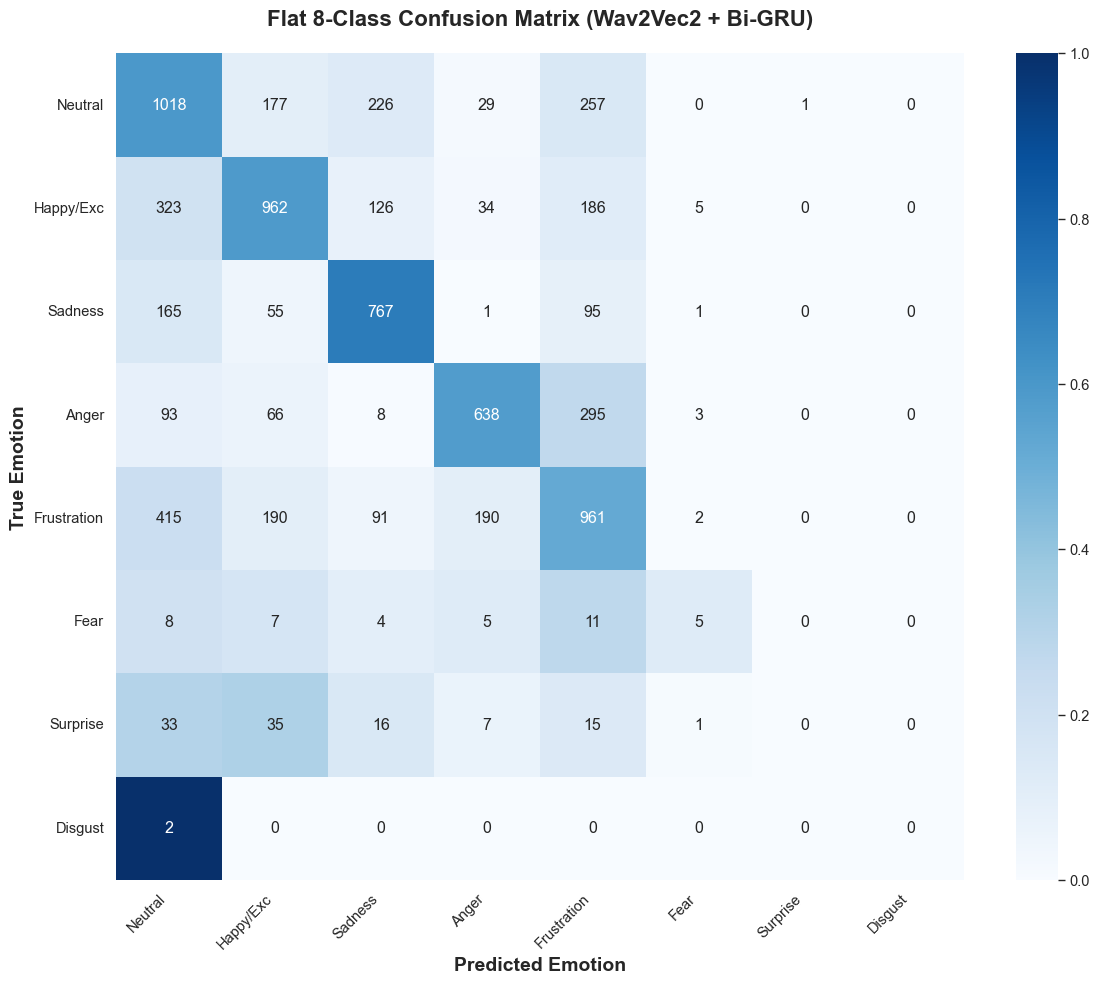

In [12]:
# =====================================================================
# 3. CONFUSION MATRIX VISUALIZATION
# =====================================================================
cm = confusion_matrix(y_true, y_pred)
# Normalize by row (True Label) to show percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_normalized = np.nan_to_num(cm_normalized) # Handle zero-division

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized, 
    annot=cm, # Show actual counts in the boxes
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0, vmax=1 # Normalize color scale from 0 to 100%
)

plt.title('Flat 8-Class Confusion Matrix (Wav2Vec2 + Bi-GRU)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Emotion', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Emotion', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()